# Reproducing Operto et al. (2013) Figure 2 — acoustic FWI radiation patterns with `sweep`

This notebook reproduces **Figure 2** of *Operto et al. (2013), "A guided tour of
multiparameter full-waveform inversion with multicomponent data", The Leading Edge
32(9), 1040–1054*.

A **radiation pattern** is the angular distribution of the scattered wave produced by a
point perturbation of one model parameter (the *partial-derivative virtual source*). It
controls multiparameter FWI **resolution** and **inter-parameter trade-off**: two parameters
whose patterns overlap over the available scattering angles are hard to separate.

Operto's figure shows this as a **2-D snapshot of the scattered wavefield** around a point
diffractor: a ring whose brightness vs azimuth *is* the radiation pattern. An **incident
source** at the top (θ=0) illuminates the **virtual source** (the point perturbation) at the
centre. The **analytic ray+Born radiation pattern is superimposed as a green curve**.

We do exactly this with `sweep`: homogeneous background, a point perturbation, record the
full wavefield, subtract the unperturbed field to isolate the scattered (Born) field, and
overlay the analytic pattern.

## The four panels (two parameterizations)

| panel | parameterization | perturb | held fixed | analytic $R(\theta)$ | ring |
|---|---|---|---|---|---|
| (a) | $(V_P,\rho)$ | $V_P$ | $\rho$ | $1$ | isotropic circle |
| (b) | $(V_P,\rho)$ | $\rho$ | $V_P$ | $1+\cos\theta$ | cardioid toward source (top) |
| (c) | $(V_P,I_P)$ | $V_P$ | $I_P$ | $1-\cos\theta$ | cardioid toward bottom (forward) |
| (d) | $(V_P,I_P)$ | $I_P$ | $V_P$ | $1+\cos\theta$ | toward top (**≡ b**) |

$\theta$ is measured from the **top** (toward the incident source). $V_P$ (bulk modulus) is a
monopole → isotropic; density radiates as a dipole that, combined with the chosen
parameterization, becomes a cardioid. **(b) and (d) are identical** because both are
"$\delta\rho$ at fixed $V_P$" — that is the point of comparing parameterizations.

In [1]:
import numpy as np, torch
import matplotlib.pyplot as plt
%matplotlib inline
import sweep
from sweep.equations import Acoustic1st
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("sweep   :", sweep.__file__)
print("device  :", DEV, "| torch", torch.__version__)

sweep   : /home/wangs0j/sweep-local/sweep-perf-fwd/src/sweep/__init__.py
device  : cuda | torch 2.9.1+cu128


## Configuration

A **large domain** (≈18 wavelengths) keeps the point-scatterer's high-wavenumber near-field
sub-resolution (so the rings look clean), while a **small scatterer** $\sigma/\lambda\approx0.05$
keeps the finite-size *form factor* $\exp(-q^2\sigma^2/2)\approx1$ so the $V_P$ ring stays
isotropic. The snapshot time is chosen so the scattered ring sits mid-frame.

In [2]:
N, DH, DT, ABCN = 360, 10.0, 0.0015, 30      # grid, spacing (m), dt (s), PML width
FREQ, DELAY = 10.0, 0.08                       # Ricker dominant freq (Hz), delay (s)
VP0, RHO0 = 2000.0, 1000.0                     # homogeneous background
CX, CZ, SRCZ = 180, 190, 40                    # virtual source (centre); incident source (top)
R_RING, SIG = 132, 0.5      # small scatterer -> form factor closer to 1                         # target ring radius (cells); scatterer width (cells)

T_STAR = (CZ - SRCZ) * DH / VP0 + DELAY + R_RING * DH / VP0
NT = int(T_STAR / DT) + 40
IT = int(round(T_STAR / DT))
SRC  = np.array([[CX, SRCZ]], dtype=np.int32)              # [x, z]
RECV = np.array([[[CX, CZ]]], dtype=np.int32)              # dummy (we use the wavefield)
WAV  = torch.tensor(ricker(np.arange(NT, dtype=np.float32) * DT - DELAY, f=FREQ), device=DEV)
zz, xx = np.mgrid[0:N, 0:N]
BLOB = np.exp(-(((xx - CX) ** 2 + (zz - CZ) ** 2) / (2 * SIG ** 2))).astype(np.float32)
print(f"grid {N}x{N}  sigma/lambda={SIG*DH/(VP0/FREQ):.3f}  snapshot t*={T_STAR:.3f}s  (it={IT}/{NT})")

grid 360x360  sigma/lambda=0.025  snapshot t*=1.490s  (it=993/1033)


## Model & geometry

Homogeneous (Vp, ρ) background with a single point perturbation (the virtual source /
diffractor) at the centre, illuminated by an incident source at the top.

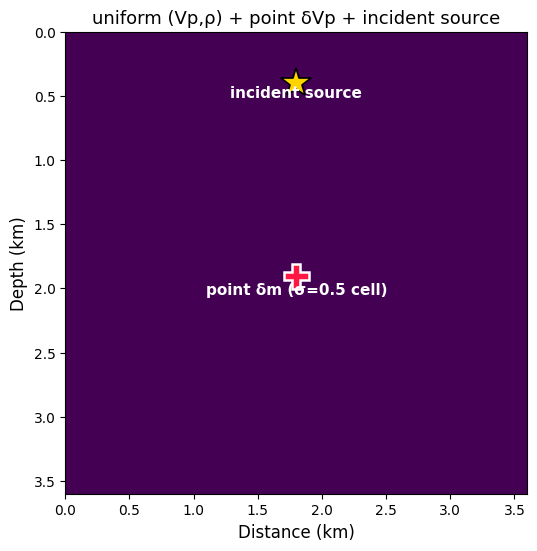

In [3]:
km = DH/1000.0
figm, axm = plt.subplots(figsize=(6,6))
axm.imshow(VP0 + 30.0*BLOB, extent=[0,N*km,N*km,0], cmap="viridis", vmin=VP0, vmax=VP0+30, aspect="equal")
axm.plot(CX*km, SRCZ*km, "*", color="#FFD400", ms=22, mec="k", mew=1.2)
axm.text(CX*km, (SRCZ+11)*km, "incident source", color="w", fontsize=11, ha="center", weight="bold")
axm.plot(CX*km, CZ*km, "P", color="#FF1744", ms=18, mec="w", mew=1.8)
axm.text(CX*km, (CZ+15)*km, f"point δm (σ={SIG} cell)", color="w", fontsize=11, ha="center", weight="bold")
axm.set_xlabel("Distance (km)", fontsize=12); axm.set_ylabel("Depth (km)", fontsize=12); axm.tick_params(labelsize=10)
axm.set_xlim(0,N*km); axm.set_ylim(N*km,0)
axm.set_title("uniform (Vp,ρ) + point δVp + incident source", fontsize=13); plt.show()

## Scattered-wavefield snapshot

We use the **first-order velocity–stress acoustic** equation `Acoustic1st` (models `(vp, rho)`), eager
backend. The full wavefield is returned with `return_wavefield=True`, which in eager mode
**requires `use_ckpt=False`** (it is incompatible with chunk checkpointing). `snap_frame`
returns the pressure field at time `IT`, cropped to the physical domain.

In [4]:
eq = Acoustic1st(spatial_order=4, device=DEV, backend="torch")
prop = PropTorch(eq, shape=(N, N), source_type=["p"], receiver_type=["p"], abcn=ABCN,
                 dh=DH, dt=DT, nt=NT, device=DEV, backend="torch", impl="eager",
                 use_ckpt=False)   # <-- needed for return_wavefield=True

def snap_frame(vp_field, rho_field):
    mt = [torch.tensor(vp_field, device=DEV, dtype=torch.float32),
          torch.tensor(rho_field, device=DEV, dtype=torch.float32)]
    with torch.no_grad():
        _, snaps = prop(WAV, SRC.copy(), RECV.copy(), models=mt, return_wavefield=True)
        fr = snaps[IT, 0, 0, 0].detach().to(torch.float32).cpu().numpy()   # field 0 = pressure
    del snaps
    if DEV == "cuda":
        torch.cuda.empty_cache()
    o0 = (fr.shape[0] - N) // 2; o1 = (fr.shape[1] - N) // 2
    return fr[o0:o0 + N, o1:o1 + N]

## Run the four scattering experiments

`du = forward(bg + δm) − forward(bg)` is the Born scattered field (verified elsewhere to
equal 1st-order Born for these weak perturbations). For the $(V_P,I_P)$ panels we build the
**joint** perturbation that keeps the *other* parameter fixed:
* (c) fix $I_P=\rho V_P$ while perturbing $V_P$  ⇒  $\delta\rho=-(\rho/V_P)\,\delta V_P$
* (d) fix $V_P$ while perturbing $I_P$  ⇒  $\delta\rho=\delta I_P/V_P$  (a pure $\delta\rho$).

In [5]:
def analytic_R(kind, a):                 # a = azimuth from top (rad)
    if kind == "iso":  return np.ones_like(a)
    if kind == "up":   return np.abs(1 + np.cos(a))   # 1 + cos θ  (max at top / toward source)
    if kind == "down": return np.abs(1 - np.cos(a))   # 1 - cos θ  (max at bottom / forward)

vp0 = np.full((N, N), VP0, np.float32); rho0 = np.full((N, N), RHO0, np.float32)
u0 = snap_frame(vp0, rho0)                            # background snapshot
dVp, dRho = 30.0, 20.0
panels = [
    ("a", r"$V_P-\rho$  (perturb $V_P$)", "iso",  vp0 + dVp * BLOB, rho0),
    ("b", r"$V_P-\rho$  (perturb $\rho$)", "up",   vp0,             rho0 + dRho * BLOB),
    ("c", r"$V_P-I_P$  (perturb $V_P$)", "down", vp0 + dVp * BLOB, rho0 - (RHO0 / VP0) * dVp * BLOB),
    ("d", r"$V_P-I_P$  (perturb $I_P$)", "up",   vp0,             rho0 + dRho * BLOB),
]
snaps = {tag: snap_frame(vpf, rhf) - u0 for tag, _, _, vpf, rhf in panels}
print("computed panels:", list(snaps))

computed panels: ['a', 'b', 'c', 'd']


## Plot — scattered wavefield (grey) + analytic radiation pattern (green)

The green curve is the analytic pattern $r(\theta)\propto|R(\theta)|$ centred on the virtual
source. The grey ring's brightness should track it: uniform for (a), top-bright for (b)/(d),
bottom-bright for (c).

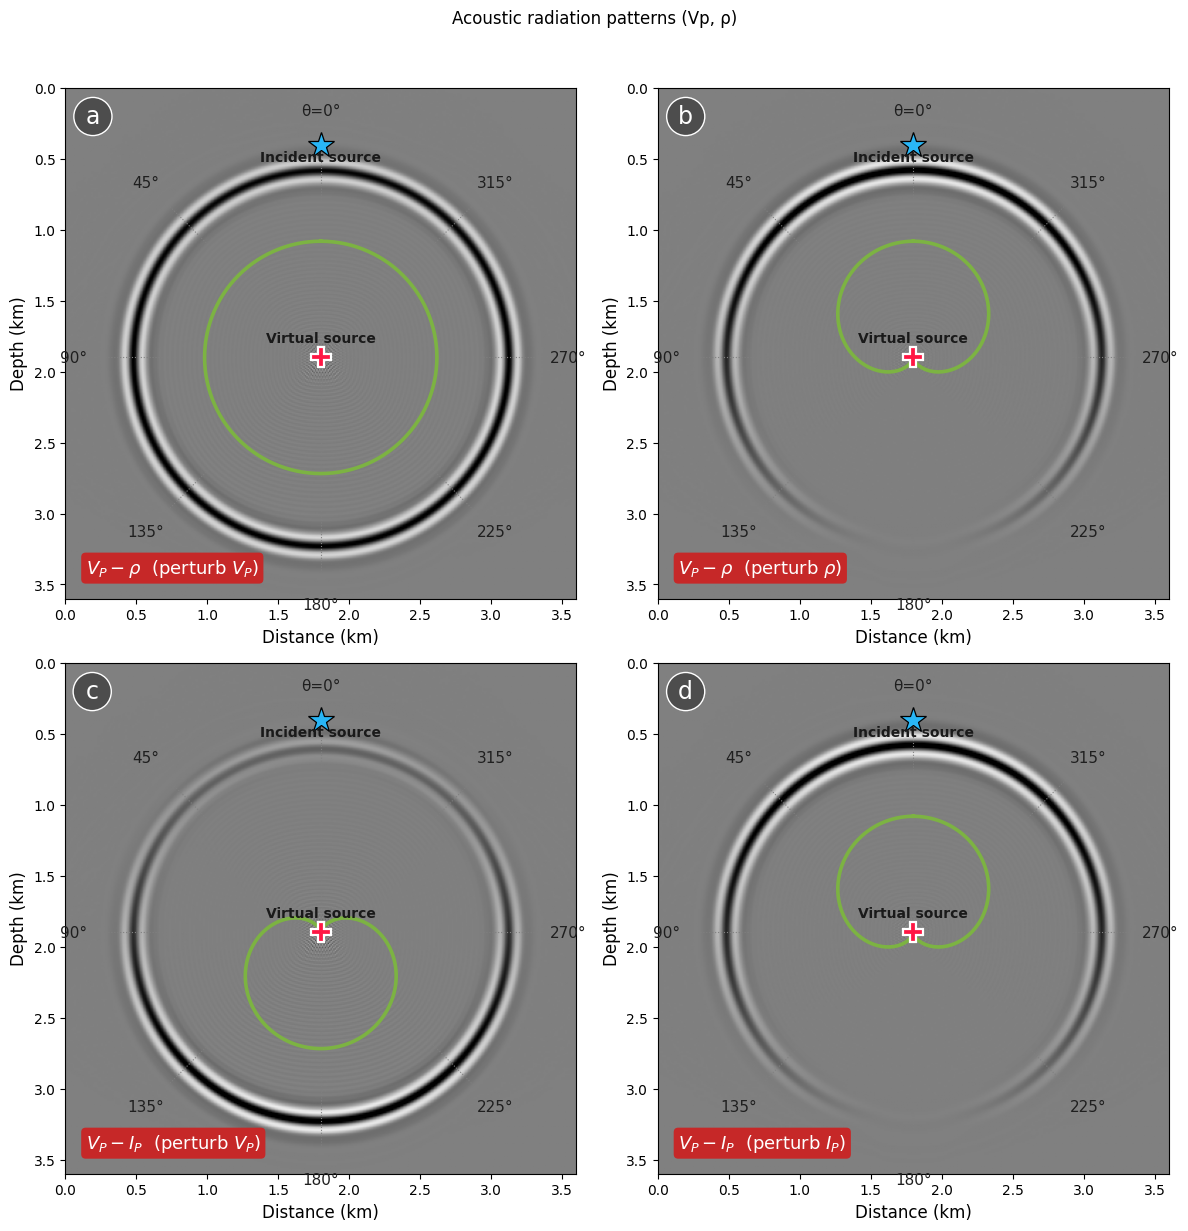

In [6]:
km = DH / 1000.0
ext = [0, N * km, N * km, 0]
cxk, czk = CX * km, CZ * km
rg = 0.62 * R_RING * km                  # green-curve reference radius

fig, axes = plt.subplots(2, 2, figsize=(12, 12.5))
for ax, (tag, lbl, kind, _, _) in zip(axes.ravel(), panels):
    d = snaps[tag]; vmax = np.percentile(np.abs(d), 99.5)
    ax.imshow(d, extent=ext, cmap="gray", vmin=-vmax, vmax=vmax, aspect="equal")
    Rk = (R_RING + 22) * km
    for ad, txt in [(0, "θ=0°"), (45, "45°"), (90, "90°"), (135, "135°"),
                    (180, "180°"), (225, "225°"), (270, "270°"), (315, "315°")]:
        a = np.radians(ad); dx, dz = -Rk * np.sin(a), -Rk * np.cos(a)
        ax.plot([cxk, cxk + dx], [czk, czk + dz], ":", color="0.5", lw=0.8)
        ax.text(cxk + dx * 1.13, czk + dz * 1.13, txt, color="0.12", fontsize=11, ha="center", va="center")
    aa = np.linspace(0, 2 * np.pi, 361); rr = analytic_R(kind, aa); rr = rr / rr.max()
    ax.plot(cxk - rg * rr * np.sin(aa), czk - rg * rr * np.cos(aa), "-", color="#7CB342", lw=2.6)
    ax.plot(CX * km, SRCZ * km, "*", color="#29B6F6", ms=19, mec="k", mew=0.9)
    ax.text(CX * km, (SRCZ + 12) * km, "Incident source", color="0.1", fontsize=10, ha="center", weight="bold")
    ax.plot(cxk, czk, "P", color="#FF1744", ms=15, mec="w", mew=1.6)
    ax.text(cxk, czk - 11 * km, "Virtual source", color="0.1", fontsize=10, ha="center", weight="bold")
    ax.text(0.04, 0.93, tag, transform=ax.transAxes, fontsize=17, color="white",
            bbox=dict(boxstyle="circle", fc="0.3", ec="white"))
    ax.text(0.04, 0.05, lbl, transform=ax.transAxes, fontsize=13, color="white",
            bbox=dict(boxstyle="round,pad=0.25", fc="#C62828", ec="none"))
    ax.set_xlabel("Distance (km)", fontsize=12); ax.set_ylabel("Depth (km)", fontsize=12); ax.tick_params(labelsize=10)
    ax.set_xlim(0, N * km); ax.set_ylim(N * km, 0)
fig.suptitle("Acoustic radiation patterns (Vp, ρ)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## Key points

* **Green curve = analytic radiation pattern** $|R(\theta)|$ (a circle or cardioid), *not* a
  fixed reference circle. The grey ring's brightness matches it.
* **(b) ≡ (d)**: both are $\delta\rho$ at fixed $V_P$ → same scattered field. (a) and (c) differ
  because fixing $\rho$ vs $I_P$ attaches a different $\delta\rho$ to the same $\delta V_P$.
* **Clean rings** come from a large domain (point-scatterer high-wavenumber near-field is
  sub-resolution) + small $\sigma$ (form factor $\approx1$, so the $V_P$ ring stays isotropic).
  For *quantitative* radiation-pattern work use a near-point scatterer ($\sigma/\lambda\lesssim0.02$).
* **`return_wavefield=True` needs `use_ckpt=False`** in the eager backend.

This is the radiation-pattern view of inter-parameter trade-off: in $(V_P,\rho)$ the $V_P$
(isotropic) and $\rho$ (forward-weak/backward) patterns overlap at small scattering angle →
short-offset trade-off; reparameterizing to $(V_P,I_P)$ redistributes the angular sensitivity.